In [2]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [3]:
!pip install -q transformers

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torchvision.utils import save_image
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt
import numpy as np
import os

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
# Download Flickr8k images and captions

!wget -q https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip
!wget -q https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip

print("Downloads completed.")

Downloads completed.


In [6]:
# Extract the downloaded files

!unzip -q Flickr8k_Dataset.zip
!unzip -q Flickr8k_text.zip

print("Dataset extraction completed.")

Dataset extraction completed.


In [7]:
import os

print("Image folder exists:",
      os.path.exists("Flicker8k_Dataset"))

print("Caption file exists:",
      os.path.exists("Flickr8k.token.txt"))

print("Number of images:",
      len(os.listdir("Flicker8k_Dataset")))

Image folder exists: True
Caption file exists: True
Number of images: 8091


In [8]:
# Load Flickr8k captions

caption_file = "Flickr8k.token.txt"

with open(caption_file, "r", encoding="utf-8") as file:
    lines = file.readlines()

print("Total caption lines:", len(lines))

# Display a few captions
for line in lines[:10]:
    print(line.strip())

Total caption lines: 40460
1000268201_693b08cb0e.jpg#0	A child in a pink dress is climbing up a set of stairs in an entry way .
1000268201_693b08cb0e.jpg#1	A girl going into a wooden building .
1000268201_693b08cb0e.jpg#2	A little girl climbing into a wooden playhouse .
1000268201_693b08cb0e.jpg#3	A little girl climbing the stairs to her playhouse .
1000268201_693b08cb0e.jpg#4	A little girl in a pink dress going into a wooden cabin .
1001773457_577c3a7d70.jpg#0	A black dog and a spotted dog are fighting
1001773457_577c3a7d70.jpg#1	A black dog and a tri-colored dog playing with each other on the road .
1001773457_577c3a7d70.jpg#2	A black dog and a white dog with brown spots are staring at each other in the street .
1001773457_577c3a7d70.jpg#3	Two dogs of different breeds looking at each other on the road .
1001773457_577c3a7d70.jpg#4	Two dogs on pavement moving toward each other .


In [9]:
import re

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = re.sub(r"[^a-z0-9\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Test preprocessing
sample_caption = (
    "A Child in a Pink Dress is Climbing up a Set of Stairs!"
)

clean_caption = preprocess_text(sample_caption)

print("Original:")
print(sample_caption)

print("\nPreprocessed:")
print(clean_caption)

Original:
A Child in a Pink Dress is Climbing up a Set of Stairs!

Preprocessed:
a child in a pink dress is climbing up a set of stairs


In [10]:
# Set device for computation

import torch

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [11]:
# Load DistilBERT tokenizer and model

from transformers import AutoTokenizer, AutoModel

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
text_encoder = AutoModel.from_pretrained(MODEL_NAME)

# Move model to GPU
text_encoder = text_encoder.to(DEVICE)

# Evaluation mode
text_encoder.eval()

print("DistilBERT loaded successfully.")
print("Device:", DEVICE)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT loaded successfully.
Device: cuda


In [12]:
def create_text_embedding(text):
    # Preprocess the text
    text = preprocess_text(text)

    # Tokenize
    inputs = tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=32
    )

    # Move inputs to GPU
    inputs = {
        key: value.to(DEVICE)
        for key, value in inputs.items()
    }

    # Generate embeddings
    with torch.no_grad():
        outputs = text_encoder(**inputs)

    # Token embeddings
    token_embeddings = outputs.last_hidden_state

    # Attention-mask-aware mean pooling
    attention_mask = inputs["attention_mask"].unsqueeze(-1)

    masked_embeddings = (
        token_embeddings * attention_mask
    )

    summed = masked_embeddings.sum(dim=1)
    counts = attention_mask.sum(dim=1)

    sentence_embedding = summed / counts

    return sentence_embedding


# Test with a real Flickr8k caption
sample_text = (
    "A child in a pink dress is climbing up a set of stairs."
)

embedding = create_text_embedding(sample_text)

print("Original text:")
print(sample_text)

print("\nEmbedding shape:")
print(embedding.shape)

print("\nFirst 10 embedding values:")
print(embedding[0, :10])

Original text:
A child in a pink dress is climbing up a set of stairs.

Embedding shape:
torch.Size([1, 768])

First 10 embedding values:
tensor([-0.0238, -0.1525, -0.0271,  0.0524,  0.4505,  0.1502,  0.1355,  0.3424,
        -0.4207, -0.2176], device='cuda:0')


In [13]:
import os
import pandas as pd

# Read Flickr8k captions
caption_data = []

with open("Flickr8k.token.txt", "r", encoding="utf-8") as file:
    for line in file:
        line = line.strip()

        if not line:
            continue

        image_id, caption = line.split("\t", 1)

        # Remove the #0, #1, etc.
        image_name = image_id.split("#")[0]

        caption_data.append({
            "image": image_name,
            "caption": caption
        })

captions_df = pd.DataFrame(caption_data)

print("Total image-caption pairs:", len(captions_df))
print("\nFirst 5 pairs:")
print(captions_df.head())

Total image-caption pairs: 40460

First 5 pairs:
                       image  \
0  1000268201_693b08cb0e.jpg   
1  1000268201_693b08cb0e.jpg   
2  1000268201_693b08cb0e.jpg   
3  1000268201_693b08cb0e.jpg   
4  1000268201_693b08cb0e.jpg   

                                             caption  
0  A child in a pink dress is climbing up a set o...  
1              A girl going into a wooden building .  
2   A little girl climbing into a wooden playhouse .  
3  A little girl climbing the stairs to her playh...  
4  A little girl in a pink dress going into a woo...  


In [14]:
from PIL import Image

IMAGE_DIR = "Flicker8k_Dataset"

sample_image_name = captions_df.iloc[0]["image"]
sample_image_path = os.path.join(
    IMAGE_DIR,
    sample_image_name
)

image = Image.open(sample_image_path)

print("Image:", sample_image_name)
print("Image size:", image.size)

Image: 1000268201_693b08cb0e.jpg
Image size: (375, 500)


In [15]:
# Create a manageable training subset

NUM_SAMPLES = 2000

# Use a fixed random seed for reproducibility
subset_df = captions_df.sample(
    n=NUM_SAMPLES,
    random_state=42
).reset_index(drop=True)

print("Training samples:", len(subset_df))
print("\nExample:")
print("Image:", subset_df.iloc[0]["image"])
print("Caption:", subset_df.iloc[0]["caption"])

Training samples: 2000

Example:
Image: 3616846215_d61881b60f.jpg
Caption: A man and two women are inside a greenhouse holding gardening tools .


In [16]:
# Image preprocessing

IMAGE_SIZE = 64

image_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

print("Image preprocessing configured.")
print("Target image size:", IMAGE_SIZE, "x", IMAGE_SIZE)

Image preprocessing configured.
Target image size: 64 x 64


In [17]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os

class FlickrTextImageDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_name = row["image"]
        caption = row["caption"]

        image_path = os.path.join(self.image_dir, image_name)

        # Load image
        image = Image.open(image_path).convert("RGB")

        # Apply image preprocessing
        if self.transform:
            image = self.transform(image)

        return {
            "image": image,
            "caption": caption
        }


# Create dataset
dataset = FlickrTextImageDataset(
    dataframe=subset_df,
    image_dir=IMAGE_DIR,
    transform=image_transform
)

print("Dataset created successfully.")
print("Number of samples:", len(dataset))

Dataset created successfully.
Number of samples: 2000


In [18]:
sample = dataset[0]

print("Image tensor shape:", sample["image"].shape)
print("Caption:", sample["caption"])

Image tensor shape: torch.Size([3, 64, 64])
Caption: A man and two women are inside a greenhouse holding gardening tools .


In [19]:
from tqdm.auto import tqdm

def create_batch_embeddings(texts, batch_size=32):
    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i:i + batch_size]

        # Preprocess captions
        batch_texts = [preprocess_text(text) for text in batch_texts]

        # Tokenize
        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=32
        )

        inputs = {
            key: value.to(DEVICE)
            for key, value in inputs.items()
        }

        # Generate embeddings
        with torch.no_grad():
            outputs = text_encoder(**inputs)

        token_embeddings = outputs.last_hidden_state
        attention_mask = inputs["attention_mask"].unsqueeze(-1)

        # Attention-mask-aware mean pooling
        masked_embeddings = token_embeddings * attention_mask
        summed = masked_embeddings.sum(dim=1)
        counts = attention_mask.sum(dim=1)

        sentence_embeddings = summed / counts

        all_embeddings.append(
            sentence_embeddings.cpu()
        )

    return torch.cat(all_embeddings, dim=0)


# Extract captions
training_captions = subset_df["caption"].tolist()

print("Creating text embeddings...")
print("Number of captions:", len(training_captions))

text_embeddings = create_batch_embeddings(
    training_captions,
    batch_size=32
)

print("\nText embedding shape:", text_embeddings.shape)

Creating text embeddings...
Number of captions: 2000


  0%|          | 0/63 [00:00<?, ?it/s]


Text embedding shape: torch.Size([2000, 768])


In [20]:
torch.save(
    text_embeddings,
    "flickr8k_text_embeddings.pt"
)

print("Text embeddings saved successfully.")

Text embeddings saved successfully.


In [21]:
class TextImageEmbeddingDataset(Dataset):
    def __init__(self, dataframe, image_dir, embeddings, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.embeddings = embeddings
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_name = row["image"]
        image_path = os.path.join(self.image_dir, image_name)

        # Load image
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # Get corresponding text embedding
        text_embedding = self.embeddings[index]

        return image, text_embedding


# Create final training dataset
train_dataset = TextImageEmbeddingDataset(
    dataframe=subset_df,
    image_dir=IMAGE_DIR,
    embeddings=text_embeddings,
    transform=image_transform
)

print("Final training dataset created.")
print("Number of samples:", len(train_dataset))

Final training dataset created.
Number of samples: 2000


In [22]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True if DEVICE.type == "cuda" else False
)

print("DataLoader created.")
print("Batch size:", BATCH_SIZE)
print("Number of batches:", len(train_loader))

DataLoader created.
Batch size: 32
Number of batches: 63


In [23]:
images, embeddings = next(iter(train_loader))

print("Images shape:", images.shape)
print("Embeddings shape:", embeddings.shape)

Images shape: torch.Size([32, 3, 64, 64])
Embeddings shape: torch.Size([32, 768])


In [24]:
import torch
import torch.nn as nn


class TextConditionedGenerator(nn.Module):
    def __init__(self, text_dim=768, noise_dim=100):
        super().__init__()

        self.noise_dim = noise_dim

        # Convert 768-dimensional DistilBERT embedding
        # into a smaller conditioning vector
        self.text_projection = nn.Sequential(
            nn.Linear(text_dim, 256),
            nn.ReLU()
        )

        # Noise + text condition
        self.fc = nn.Sequential(
            nn.Linear(noise_dim + 256, 512 * 4 * 4),
            nn.BatchNorm1d(512 * 4 * 4),
            nn.ReLU()
        )

        # 4x4 -> 8x8 -> 16x16 -> 32x32 -> 64x64
        self.upsampling = nn.Sequential(

            nn.ConvTranspose2d(
                512, 256,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(
                256, 128,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(
                128, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(
                64, 3,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.Tanh()
        )

    def forward(self, noise, text_embedding):

        # Text embedding: [batch, 768]
        text_features = self.text_projection(text_embedding)

        # Combine random noise and text information
        combined = torch.cat(
            [noise, text_features],
            dim=1
        )

        # Convert to feature map
        x = self.fc(combined)

        x = x.view(
            x.size(0),
            512,
            4,
            4
        )

        # Generate image
        image = self.upsampling(x)

        return image


# Create Generator
NOISE_DIM = 100
TEXT_DIM = 768

generator = TextConditionedGenerator(
    text_dim=TEXT_DIM,
    noise_dim=NOISE_DIM
).to(DEVICE)

print(generator)

TextConditionedGenerator(
  (text_projection): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): ReLU()
  )
  (fc): Sequential(
    (0): Linear(in_features=356, out_features=8192, bias=True)
    (1): BatchNorm1d(8192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (upsampling): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 

In [25]:
# Test generator with one training batch

images, embeddings = next(iter(train_loader))

batch_size = images.size(0)

noise = torch.randn(
    batch_size,
    NOISE_DIM,
    device=DEVICE
)

embeddings = embeddings.to(DEVICE)

with torch.no_grad():
    generated_images = generator(
        noise,
        embeddings
    )

print("Generated image shape:", generated_images.shape)

Generated image shape: torch.Size([32, 3, 64, 64])


In [26]:
class CrossAttention(nn.Module):
    def __init__(self, image_channels, text_dim, attention_dim=128):
        super().__init__()

        self.query = nn.Linear(image_channels, attention_dim)
        self.key = nn.Linear(text_dim, attention_dim)
        self.value = nn.Linear(text_dim, attention_dim)

        self.output = nn.Linear(
            attention_dim,
            image_channels
        )

        self.scale = attention_dim ** 0.5

    def forward(self, image_features, text_embedding):
        """
        image_features:
            [batch, channels, height, width]

        text_embedding:
            [batch, 768]
        """

        batch_size, channels, height, width = image_features.shape

        # Convert image feature map into sequence
        image_sequence = image_features.view(
            batch_size,
            channels,
            height * width
        ).permute(0, 2, 1)

        # Query from image features
        query = self.query(image_sequence)

        # Key and Value from text
        key = self.key(text_embedding).unsqueeze(1)
        value = self.value(text_embedding).unsqueeze(1)

        # Attention scores
        attention_scores = torch.bmm(
            query,
            key.transpose(1, 2)
        ) / self.scale

        attention_weights = torch.softmax(
            attention_scores,
            dim=-1
        )

        # Apply attention to text information
        attended_text = torch.bmm(
            attention_weights,
            value
        )

        # Convert back to image feature dimensions
        attended_text = self.output(attended_text)

        # Residual connection
        output = image_sequence + attended_text

        # Restore feature-map format
        output = output.permute(
            0, 2, 1
        ).view(
            batch_size,
            channels,
            height,
            width
        )

        return output

In [27]:
class AttentionTextConditionedGenerator(nn.Module):
    def __init__(self, text_dim=768, noise_dim=100):
        super().__init__()

        self.text_projection = nn.Sequential(
            nn.Linear(text_dim, 256),
            nn.ReLU()
        )

        self.fc = nn.Sequential(
            nn.Linear(noise_dim + 256, 512 * 4 * 4),
            nn.BatchNorm1d(512 * 4 * 4),
            nn.ReLU()
        )

        # First upsampling block
        self.block1 = nn.Sequential(
            nn.ConvTranspose2d(
                512, 256,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )

        # Cross-attention after 8x8 feature map
        self.cross_attention = CrossAttention(
            image_channels=256,
            text_dim=text_dim,
            attention_dim=128
        )

        # Continue image generation
        self.block2 = nn.Sequential(
            nn.ConvTranspose2d(
                256, 128,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(
                128, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(
                64, 3,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.Tanh()
        )

    def forward(self, noise, text_embedding):

        # Project text embedding
        text_features = self.text_projection(
            text_embedding
        )

        # Combine noise + text
        combined = torch.cat(
            [noise, text_features],
            dim=1
        )

        # Create initial feature map
        x = self.fc(combined)

        x = x.view(
            x.size(0),
            512,
            4,
            4
        )

        # 4x4 -> 8x8
        x = self.block1(x)

        # Apply cross-attention
        x = self.cross_attention(
            x,
            text_embedding
        )

        # 8x8 -> 64x64
        x = self.block2(x)

        return x


# Create attention-based Generator
generator = AttentionTextConditionedGenerator(
    text_dim=TEXT_DIM,
    noise_dim=NOISE_DIM
).to(DEVICE)

print("Attention-based Generator created.")

Attention-based Generator created.


In [28]:
images, embeddings = next(iter(train_loader))

batch_size = images.size(0)

noise = torch.randn(
    batch_size,
    NOISE_DIM,
    device=DEVICE
)

embeddings = embeddings.to(DEVICE)

with torch.no_grad():
    generated_images = generator(
        noise,
        embeddings
    )

print("Generated image shape:", generated_images.shape)

Generated image shape: torch.Size([32, 3, 64, 64])


In [29]:
class TextConditionedDiscriminator(nn.Module):
    def __init__(self, text_dim=768):
        super().__init__()

        # Image feature extractor
        self.image_features = nn.Sequential(

            # 64x64 -> 32x32
            nn.Conv2d(
                3, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32x32 -> 16x16
            nn.Conv2d(
                64, 128,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # 16x16 -> 8x8
            nn.Conv2d(
                128, 256,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # 8x8 -> 4x4
            nn.Conv2d(
                256, 512,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True)
        )

        # Text embedding projection
        self.text_projection = nn.Sequential(
            nn.Linear(text_dim, 256),
            nn.LeakyReLU(0.2, inplace=True)
        )

        # Final discriminator
        self.classifier = nn.Sequential(
            nn.Linear(
                512 * 4 * 4 + 256,
                1
            ),
            nn.Sigmoid()
        )

    def forward(self, image, text_embedding):

        # Extract image features
        image_features = self.image_features(image)

        image_features = image_features.view(
            image_features.size(0),
            -1
        )

        # Process text embedding
        text_features = self.text_projection(
            text_embedding
        )

        # Combine image + text
        combined = torch.cat(
            [image_features, text_features],
            dim=1
        )

        # Real/fake probability
        output = self.classifier(combined)

        return output


# Create Discriminator
discriminator = TextConditionedDiscriminator(
    text_dim=TEXT_DIM
).to(DEVICE)

print("Discriminator created.")

Discriminator created.


In [30]:
images, embeddings = next(iter(train_loader))

images = images.to(DEVICE)
embeddings = embeddings.to(DEVICE)

with torch.no_grad():
    predictions = discriminator(
        images,
        embeddings
    )

print("Discriminator output shape:", predictions.shape)
print("Example prediction:", predictions[0].item())

Discriminator output shape: torch.Size([32, 1])
Example prediction: 0.5883083939552307


In [31]:
# GAN training configuration

LEARNING_RATE = 0.0002
BETA1 = 0.5
BETA2 = 0.999

criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(
    generator.parameters(),
    lr=LEARNING_RATE,
    betas=(BETA1, BETA2)
)

optimizer_D = torch.optim.Adam(
    discriminator.parameters(),
    lr=LEARNING_RATE,
    betas=(BETA1, BETA2)
)

print("GAN training configuration ready.")
print("Learning rate:", LEARNING_RATE)
print("Loss function: Binary Cross-Entropy")

GAN training configuration ready.
Learning rate: 0.0002
Loss function: Binary Cross-Entropy


In [32]:
import os

OUTPUT_DIR = "generated_images"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print("Output folder:", OUTPUT_DIR)

Output folder: generated_images


In [33]:
# Fixed captions for monitoring training progress

test_captions = [
    "a child playing outdoors",
    "a dog running through grass",
    "a man riding a bicycle",
    "a group of people walking",
    "a bird sitting on a branch",
    "a person standing near a building",
    "a dog playing with a ball",
    "a child running outside"
]

# Create fixed text embeddings
test_embeddings = create_batch_embeddings(
    test_captions,
    batch_size=8
).to(DEVICE)

# Fixed random noise
torch.manual_seed(42)

test_noise = torch.randn(
    len(test_captions),
    NOISE_DIM,
    device=DEVICE
)

print("Test captions:", len(test_captions))
print("Test embedding shape:", test_embeddings.shape)
print("Test noise shape:", test_noise.shape)

  0%|          | 0/1 [00:00<?, ?it/s]

Test captions: 8
Test embedding shape: torch.Size([8, 768])
Test noise shape: torch.Size([8, 100])


In [34]:
def train_gan(epochs=1):

    generator.train()
    discriminator.train()

    for epoch in range(epochs):

        total_g_loss = 0
        total_d_loss = 0

        progress_bar = tqdm(
            train_loader,
            desc=f"Epoch {epoch + 1}/{epochs}"
        )

        for real_images, text_embeddings in progress_bar:

            real_images = real_images.to(DEVICE)
            text_embeddings = text_embeddings.to(DEVICE)

            batch_size = real_images.size(0)

            # Labels
            real_labels = torch.ones(
                batch_size, 1,
                device=DEVICE
            )

            fake_labels = torch.zeros(
                batch_size, 1,
                device=DEVICE
            )

            # =====================================
            # Train Discriminator
            # =====================================

            optimizer_D.zero_grad()

            # Real images
            real_output = discriminator(
                real_images,
                text_embeddings
            )

            real_loss = criterion(
                real_output,
                real_labels
            )

            # Generate fake images
            noise = torch.randn(
                batch_size,
                NOISE_DIM,
                device=DEVICE
            )

            fake_images = generator(
                noise,
                text_embeddings
            )

            # Fake images
            fake_output = discriminator(
                fake_images.detach(),
                text_embeddings
            )

            fake_loss = criterion(
                fake_output,
                fake_labels
            )

            # Total discriminator loss
            d_loss = real_loss + fake_loss

            d_loss.backward()
            optimizer_D.step()

            # =====================================
            # Train Generator
            # =====================================

            optimizer_G.zero_grad()

            fake_output = discriminator(
                fake_images,
                text_embeddings
            )

            g_loss = criterion(
                fake_output,
                real_labels
            )

            g_loss.backward()
            optimizer_G.step()

            total_d_loss += d_loss.item()
            total_g_loss += g_loss.item()

            progress_bar.set_postfix({
                "D_loss": f"{d_loss.item():.4f}",
                "G_loss": f"{g_loss.item():.4f}"
            })

        avg_d_loss = total_d_loss / len(train_loader)
        avg_g_loss = total_g_loss / len(train_loader)

        print(
            f"\nEpoch [{epoch + 1}/{epochs}] "
            f"D Loss: {avg_d_loss:.4f} "
            f"G Loss: {avg_g_loss:.4f}"
        )

        # =====================================
        # Generate sample images
        # =====================================

        generator.eval()

        with torch.no_grad():
            samples = generator(
                test_noise,
                test_embeddings
            )

        # Convert from [-1, 1] to [0, 1]
        samples = (samples + 1) / 2

        save_path = os.path.join(
            OUTPUT_DIR,
            f"epoch_{epoch + 1}.png"
        )

        save_image(
            samples,
            save_path,
            nrow=4
        )

        print("Saved:", save_path)

        generator.train()

In [35]:
train_gan(epochs=1)

Epoch 1/1:   0%|          | 0/63 [00:00<?, ?it/s]


Epoch [1/1] D Loss: 0.6650 G Loss: 8.8518
Saved: generated_images/epoch_1.png


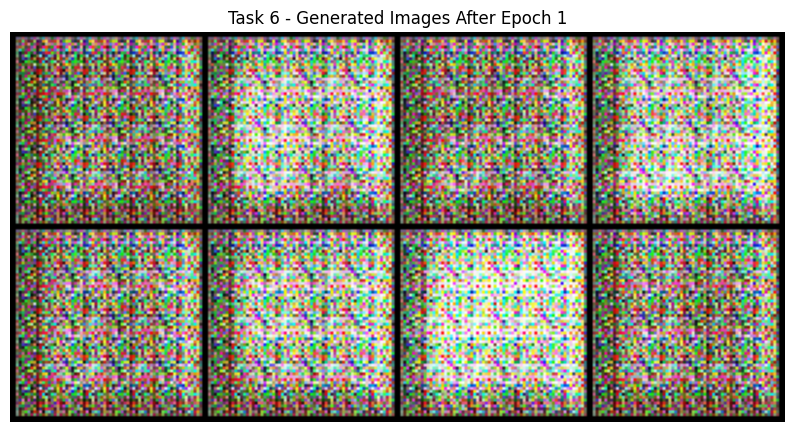

In [36]:
import matplotlib.pyplot as plt
from PIL import Image

image_path = "generated_images/epoch_1.png"

image = Image.open(image_path)

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis("off")
plt.title("Task 6 - Generated Images After Epoch 1")
plt.show()

In [37]:
train_gan(epochs=5)

Epoch 1/5:   0%|          | 0/63 [00:00<?, ?it/s]


Epoch [1/5] D Loss: 0.7103 G Loss: 3.2019
Saved: generated_images/epoch_1.png


Epoch 2/5:   0%|          | 0/63 [00:00<?, ?it/s]


Epoch [2/5] D Loss: 0.6937 G Loss: 3.4368
Saved: generated_images/epoch_2.png


Epoch 3/5:   0%|          | 0/63 [00:00<?, ?it/s]

...

Epoch 4/5:   0%|          | 0/63 [00:00<?, ?it/s]


Epoch [4/5] D Loss: 0.6330 G Loss: 3.4045
Saved: generated_images/epoch_4.png


Epoch 5/5:   0%|          | 0/63 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d14fcf0e160>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d14fcf0e160>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Exception ignored in:     <function _MultiProcessingDataLoaderIter.__del__ at 0x7d14fcf0e160>self._shutdown_workers()

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/d


Epoch [5/5] D Loss: 0.6669 G Loss: 3.7143
Saved: generated_images/epoch_5.png


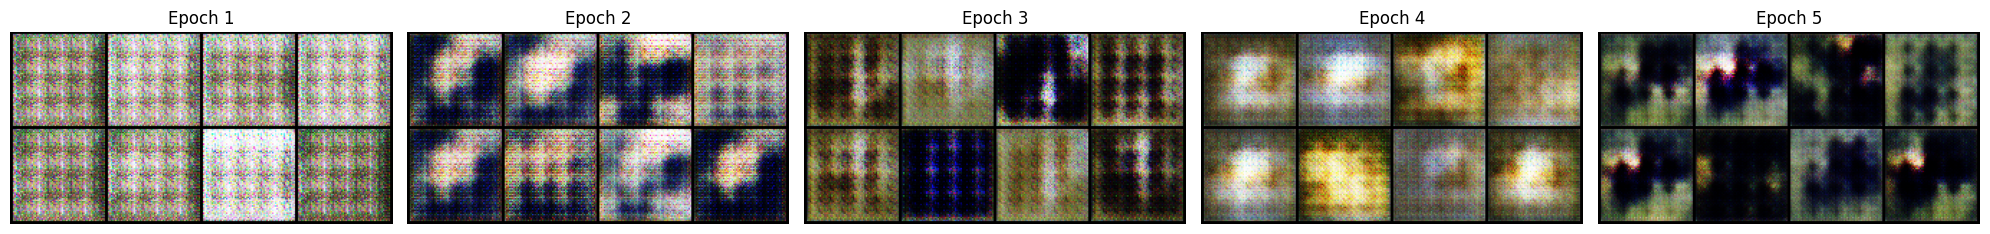

In [38]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(1, 6):
    image_path = f"generated_images/epoch_{i}.png"
    image = Image.open(image_path)

    axes[i - 1].imshow(image)
    axes[i - 1].set_title(f"Epoch {i}")
    axes[i - 1].axis("off")

plt.tight_layout()
plt.show()

In [39]:
torch.save(
    generator.state_dict(),
    "task6_generator.pth"
)

torch.save(
    discriminator.state_dict(),
    "task6_discriminator.pth"
)

print("Generator saved.")
print("Discriminator saved.")

Generator saved.
Discriminator saved.


In [40]:
torch.save(generator.state_dict(), "task6_generator.pth")
torch.save(discriminator.state_dict(), "task6_discriminator.pth")

print("Generator saved successfully.")
print("Discriminator saved successfully.")

Generator saved successfully.
Discriminator saved successfully.
